# Levels and a Puzzle Generator

*A worked walkthrough of turning the solvers and learners of the first two notebooks into playable content: a level format, two hand-built worlds, a generator for new puzzles, a difficulty measure, and a first "design" puzzle solved with an inverse LP. The design choices draw on the procedural content generation literature (Togelius et al., 2011; Shaker, Togelius & Nelson, 2016) and on GAMUT, a standard generator of test games (Nudelman et al., 2004). Full references are at the end.*

Up to now we have asked questions *about* games. Here the games become the product. That changes what we care about. A solver only needs a correct answer; a puzzle also needs to be fair (the answer can be checked), readable (a person can reason about it), and graded (it teaches one idea at a time and gets harder at the right pace).

The plan:

| § | Topic | Main functions |
|---|---|---|
| 1 | Tools from notebooks 01 and 02 | `support_enumeration`, `nash_conv`, ... |
| 2 | A level format | `make_level`, `validate_level` |
| 3 | World 1: pure strategies (hand-built) | |
| 4 | World 2: mixed strategies (hand-built) | |
| 5 | Design mode: making an outcome stable | `min_change_to_equilibrium` |
| 6 | A generator | `random_game`, `game_features`, `generate` |
| 7 | How hard is a puzzle? | `learning_rounds` |
| 8 | Exporting the levels | `export_world` |
| 9 | Discussion | |

The output of this notebook is a set of JSON files in `levels/`. The browser game will read only these files. Everything that needs Python (solving, generating, measuring difficulty) happens here, ahead of time, which is what lets the game run as a static page on GitHub Pages.

In [1]:
# %pip install numpy scipy pandas matplotlib
import itertools
import json
from fractions import Fraction
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

TOL = 1e-8
np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1 · Tools from notebooks 01 and 02

The same functions as before, with short docstrings, so that the notebook runs on its own. In the repository they come from `engine/solvers.py` and `engine/learners.py`. The regret-matching learner is trimmed to what section 7 needs: it only returns the empirical frequencies.

In [2]:
def pure(k, n):
    '''Pure strategy "always play k" (counted from 0) as a probability vector of length n.'''
    v = np.zeros(n); v[k] = 1.0
    return v


def best_response(M, y):
    '''All pure best responses (rows of M) to the opponent's mix y, ties included.'''
    vals = M @ y
    return np.flatnonzero(vals >= vals.max() - TOL)


def is_nash(A, B, x, y):
    '''True if (x, y) is a Nash equilibrium of (A, B).'''
    return bool((A @ y).max() <= x @ A @ y + TOL and (x @ B).max() <= x @ B @ y + TOL)


def nash_conv(A, B, x, y):
    '''Total gain available to the two players from unilateral deviation (0 at equilibrium).'''
    return float((A @ y).max() - x @ A @ y + (x @ B).max() - x @ B @ y)


def pure_nash(A, B):
    '''All pure-strategy equilibria as (row, col) pairs.'''
    m, n = A.shape
    return [(i, j) for i in range(m) for j in range(n)
            if i in best_response(A, pure(j, n)) and j in best_response(B.T, pure(i, m))]


def eliminate_dominated(A, B):
    '''Iterated elimination of strictly dominated pure strategies; returns surviving (rows, cols).'''
    rows, cols = list(range(A.shape[0])), list(range(A.shape[1]))

    def dominated(M):
        for i in range(M.shape[0]):
            for k in range(M.shape[0]):
                if k != i and np.all(M[k] > M[i]):
                    return i
        return None

    changed = True
    while changed:
        changed = False
        d = dominated(A[np.ix_(rows, cols)])
        if d is not None:
            rows.pop(d); changed = True
        d = dominated(B[np.ix_(rows, cols)].T)
        if d is not None:
            cols.pop(d); changed = True
    return rows, cols


def solve_indifference(M, rows, cols):
    '''Opponent mix on cols that makes this player indifferent over rows (None if singular).'''
    k = len(rows)
    S = np.zeros((k + 1, k + 1)); rhs = np.zeros(k + 1)
    S[:k, :k] = M[np.ix_(rows, cols)]; S[:k, k] = -1; S[k, :k] = 1; rhs[k] = 1
    try:
        sol = np.linalg.solve(S, rhs)
    except np.linalg.LinAlgError:
        return None
    y = np.zeros(M.shape[1]); y[list(cols)] = sol[:k]
    return y


def support_enumeration(A, B):
    '''All Nash equilibria of a nondegenerate bimatrix game.'''
    m, n = A.shape
    eqs = []
    for k in range(1, min(m, n) + 1):
        for rows in itertools.combinations(range(m), k):
            for cols in itertools.combinations(range(n), k):
                y = solve_indifference(A, rows, cols)
                x = solve_indifference(B.T, cols, rows)
                if x is None or y is None or (x < -TOL).any() or (y < -TOL).any():
                    continue
                x, y = np.clip(x, 0, None), np.clip(y, 0, None)
                if is_nash(A, B, x, y):
                    eqs.append((x, y))
    return eqs


def regret_matching_averages(A, B, T, seed=0):
    '''Empirical frequencies of play under unconditional regret matching, shape (T, m) and (T, n).'''
    rng = np.random.default_rng(seed)
    m, n = A.shape
    R_x, R_y = np.zeros(m), np.zeros(n)
    c_x, c_y = np.zeros(m), np.zeros(n)
    X, Y = np.zeros((T, m)), np.zeros((T, n))
    for t in range(T):
        px, py = np.maximum(R_x, 0), np.maximum(R_y, 0)
        px = px / px.sum() if px.sum() > 0 else np.ones(m) / m
        py = py / py.sum() if py.sum() > 0 else np.ones(n) / n
        i, j = rng.choice(m, p=px), rng.choice(n, p=py)
        R_x += A[:, j] - A[i, j]
        R_y += B[i, :] - B[i, j]
        c_x[i] += 1; c_y[j] += 1
        X[t], Y[t] = c_x / (t + 1), c_y / (t + 1)
    return X, Y

## 2 · A level format

A level has to carry everything the browser needs: the game, how to present it, what the player is asked to do, how an answer is checked, and the solution for hints or a "show answer" button. Everything else (how the level was found, its difficulty) is stored alongside for sorting and analysis.

We use three **tasks**:

- `all_pure`: click every pure equilibrium, or declare that there is none. The answer is a set of cells, checked for exact equality.
- `mixed`: set probabilities with sliders until neither player wants to deviate. The answer is checked by computing NashConv in the browser, which is a few lines of JavaScript. Any equilibrium passes; if the game also has pure equilibria we can require a fully mixed answer, so that the level tests what it is meant to test.
- `design`: change payoffs so that a given cell becomes an equilibrium, as cheaply as possible (section 5).

**Tolerance for sliders.** Sliders move in steps of 0.01, so an exact equilibrium is often unreachable. We accept any profile whose NashConv is at most 3% of the game's payoff range. Scaling by the range makes the rule independent of units: multiplying all payoffs by 10 leaves the level equally hard.

**Why check with NashConv rather than compare with the stored solution?** Because it is the definition. A comparison would reject a correct answer that differs from ours in the second decimal place, or a different equilibrium we forgot to list. Checking the equilibrium condition directly is both simpler and fairer.

In [3]:
def _round(v, d=6):
    return [round(float(a), d) for a in np.ravel(v)]


def payoff_range(A, B):
    '''Largest minus smallest payoff over both matrices.'''
    return float(max(A.max(), B.max()) - min(A.min(), B.min()))


def make_level(id, world, order, title, concept, story, task, players, row_labels, col_labels,
               A, B, hints, require_fully_mixed=False, target=None, margin=1.0, known_as=None):
    '''Build a level dictionary, computing the solution and the answer check from the game.

    Parameters
    ----------
    id : str
        Unique identifier, e.g. "w1-01".
    world, order : int
        Position of the level in the game.
    title, concept, story : str
        Display texts: the level name, the idea it teaches, and a one-paragraph setting.
    task : {"all_pure", "mixed", "design"}
        What the player is asked to do.
    players : [str, str]
        Names of the row and the column player.
    row_labels, col_labels : list of str
        Names of the strategies.
    A, B : array-like, shape (m, n)
        Payoff matrices of the row and the column player.
    hints : list of str
        Hints shown one at a time.
    require_fully_mixed : bool
        For task "mixed": reject answers in which a player uses a single strategy.
    target : (int, int)
        For task "design": the cell that must become an equilibrium.
    margin : float
        For task "design": how much better the target must be than any deviation.
    known_as : str, optional
        The game's standard name in the literature, e.g. "the Prisoner's Dilemma".

    Returns
    -------
    dict ready to be written as JSON.
    '''
    A, B = np.asarray(A, float), np.asarray(B, float)
    level = dict(id=id, world=world, order=order, title=title, concept=concept, story=story,
                 task=task, players=players, row_labels=row_labels, col_labels=col_labels,
                 A=A.tolist(), B=B.tolist(), hints=hints)
    if known_as:
        level["known_as"] = known_as
    eqs = support_enumeration(A, B)
    if task == "all_pure":
        level["check"] = {"type": "pure_set"}
        level["solution"] = {"pure": [list(map(int, c)) for c in pure_nash(A, B)]}
    elif task == "mixed":
        level["check"] = {"type": "nash_conv", "tolerance": round(0.03 * payoff_range(A, B), 4),
                          "require_fully_mixed": require_fully_mixed}
        sols = [(x, y) for x, y in eqs
                if not require_fully_mixed or ((x > TOL).sum() > 1 and (y > TOL).sum() > 1)]
        level["solution"] = {"mixed": [{"x": _round(x), "y": _round(y)} for x, y in sols]}
    elif task == "design":
        dA, dB, cost = min_change_to_equilibrium(A, B, target, margin)
        level["check"] = {"type": "design", "target": list(target), "margin": margin,
                          "optimal_cost": round(cost, 4)}
        level["solution"] = {"dA": np.round(dA, 4).tolist(), "dB": np.round(dB, 4).tolist()}
    else:
        raise ValueError(f"unknown task {task}")
    return level


def validate_level(level):
    '''Recompute everything from the stored game and raise AssertionError on any inconsistency.'''
    A, B = np.array(level["A"]), np.array(level["B"])
    m, n = A.shape
    assert B.shape == (m, n), "A and B must have the same shape"
    assert len(level["row_labels"]) == m and len(level["col_labels"]) == n, "label count"
    assert len(level["hints"]) >= 1, "at least one hint"
    check = level["check"]
    if check["type"] == "pure_set":
        stored = sorted(map(tuple, level["solution"]["pure"]))
        assert stored == sorted(pure_nash(A, B)), "stored pure equilibria are wrong"
    elif check["type"] == "nash_conv":
        sols = level["solution"]["mixed"]
        assert len(sols) >= 1, "no admissible equilibrium"
        for s in sols:
            x, y = np.array(s["x"]), np.array(s["y"])
            assert nash_conv(A, B, x, y) < 1e-4, "stored solution is not an equilibrium"
            if check["require_fully_mixed"]:
                assert (x > TOL).sum() > 1 and (y > TOL).sum() > 1
        assert check["tolerance"] > 0
    elif check["type"] == "design":
        dA, dB = np.array(level["solution"]["dA"]), np.array(level["solution"]["dB"])
        i, j = check["target"]
        A2, B2 = A + dA, B + dB
        assert np.all(A2[i, j] >= np.delete(A2[:, j], i) + check["margin"] - 1e-6)
        assert np.all(B2[i, j] >= np.delete(B2[i, :], j) + check["margin"] - 1e-6)
        assert abs(np.abs(dA).sum() + np.abs(dB).sum() - check["optimal_cost"]) < 1e-3
    return True

`make_level` calls `min_change_to_equilibrium`, which is defined in section 5. Python only looks the name up when the function runs, so the order of definitions does not matter as long as section 5 has been executed before the first design level is built.

## 3 · World 1: pure strategies

Each level introduces one idea, in an order where every idea builds on the previous one:

1. **A dominant strategy**: one action is best whatever the other player does.
2. **One dominant strategy is enough**: only one player has a dominant action, but once she uses it the other player's choice is obvious.
3. **Iterated dominance**: nobody has a dominant action at the start; deleting bad options step by step leaves one cell.
4. **Several equilibria**: the equilibrium concept does not always pick a single outcome.
5. **No pure equilibrium**: "none" is a correct answer, and a teaser for World 2.

The design level of section 5 closes the world.

In [4]:
world1 = [
    make_level(
        "w1-01", 1, 1, "Two Suspects", "Dominant strategy",
        "Two suspects are questioned in separate rooms. Each can stay silent or confess. "
        "Staying silent together gets both a light sentence; a confession frees the confessor "
        "and hurts the other. Payoffs are years of freedom kept (higher is better).",
        "all_pure", ["Suspect A", "Suspect B"], ["Silent", "Confess"], ["Silent", "Confess"],
        [[3, 0], [5, 1]], [[3, 5], [0, 1]],
        ["Fix what B does. Is Confess better for A in both cases?",
         "If each player has one action that is always better, the equilibrium is where both use it."]),

    make_level(
        "w1-02", 1, 2, "The Market Leader", "One dominant strategy is enough",
        "A large firm chooses a high or low price; a small rival then decides whether to enter. "
        "The large firm's best price does not depend on the rival. The rival's choice does.",
        "all_pure", ["Leader", "Rival"], ["High price", "Low price"], ["Enter", "Stay out"],
        [[5, 7], [3, 4]], [[3, 0], [-1, 0]],
        ["Only one of the two players has a dominant action. Which one?",
         "Assume that player uses it. What is the other player's best reply?"]),

    make_level(
        "w1-03", 1, 3, "Peel the Onion", "Iterated elimination of dominated strategies",
        "No player has an action that is best in every case. But some actions are never best. "
        "Remove them and look again.",
        "all_pure", ["Row", "Column"], ["U", "M", "D"], ["L", "C", "R"],
        [[4, 5, 6], [2, 8, 3], [3, 9, 2]], [[3, 1, 2], [1, 4, 6], [0, 6, 8]],
        ["Start with the column player. Compare C and R row by row.",
         "Once C is gone, compare U with M and with D.",
         "One cell survives."]),

    make_level(
        "w1-04", 1, 4, "Which Side of the Road?", "Multiple equilibria",
        "Two drivers approach each other on a narrow road. Both want to avoid a collision; "
        "keeping left is slightly more comfortable for both.",
        "all_pure", ["Driver 1", "Driver 2"], ["Keep left", "Keep right"], ["Keep left", "Keep right"],
        [[2, 0], [0, 1]], [[2, 0], [0, 1]],
        ["Check every cell: would either driver want to switch?",
         "There is more than one answer. Select all of them."]),

    make_level(
        "w1-05", 1, 5, "Heads or Tails", "No pure equilibrium",
        "The row player wins if the coins match, the column player wins if they differ.",
        "all_pure", ["Matcher", "Mismatcher"], ["Heads", "Tails"], ["Heads", "Tails"],
        [[1, -1], [-1, 1]], [[-1, 1], [1, -1]],
        ["Start from any cell and let the unhappy player switch. Where do you end up?",
         "If every cell has an unhappy player, the right answer is \"none\"."]),
]

In [5]:
for lv in world1:
    print(f'{lv["id"]}  {lv["title"]:24s} {lv["concept"]:45s} solution: {lv["solution"]["pure"]}')

w1-01  Two Suspects             Dominant strategy                             solution: [[1, 1]]
w1-02  The Market Leader        One dominant strategy is enough               solution: [[0, 0]]
w1-03  Peel the Onion           Iterated elimination of dominated strategies  solution: [[0, 0]]
w1-04  Which Side of the Road?  Multiple equilibria                           solution: [[0, 0], [1, 1]]
w1-05  Heads or Tails           No pure equilibrium                           solution: []


Level 2 deserves a check by hand. The leader's first row pays 5 or 7 and the second row 3 or 4, so High price is dominant. The rival has no dominant action (entering is good against a high price and bad against a low one). Given High price, the rival enters, and (High price, Enter) is the only equilibrium. The solver agrees.

## 4 · World 2: mixed strategies

World 2 asks for probabilities. The key idea is the indifference principle from notebook 01: a player mixes only between actions that pay the same, and her own probabilities are what make the *other* player indifferent. The hints are written to lead there.

1. **The fair coin**: matching pennies, where symmetry gives the answer away.
2. **Uneven stakes**: a zero-sum game where the answer is not 50–50 and has to be computed.
3. **Penalty kick**: an empirical classic. Kickers and goalkeepers in professional football mix sides in proportions close to the minimax prediction (Chiappori, Levitt & Groseclose, 2002; Palacios-Huerta, 2003). The payoffs are scoring probabilities in percent, stylised from those studies rather than taken from their data.
4. **The mixed compromise**: battle of the sexes has two pure equilibria, so the level requires a fully mixed answer.
5. **Three options**: rock-paper-scissors, the first 3×3 mixed level.

In [6]:
world2 = [
    make_level(
        "w2-01", 2, 1, "The Fair Coin", "Mixed equilibrium by symmetry",
        "The same matching game as before. There is no pure equilibrium, so each player must randomise. "
        "How?",
        "mixed", ["Matcher", "Mismatcher"], ["Heads", "Tails"], ["Heads", "Tails"],
        [[1, -1], [-1, 1]], [[-1, 1], [1, -1]],
        ["If your opponent could predict you, she would win. What mix is impossible to exploit?"]),

    make_level(
        "w2-02", 2, 2, "Uneven Stakes", "Indifference principle",
        "A zero-sum game where one outcome is worth more than the others. The answer is not 50-50.",
        "mixed", ["Row", "Column"], ["Up", "Down"], ["Left", "Right"],
        [[2, -1], [-1, 1]], [[-2, 1], [1, -1]],
        ["Choose your probability p of Up so that the column player earns the same with Left and with Right.",
         "Write the column player's payoff for Left and for Right as functions of p and set them equal."]),

    make_level(
        "w2-03", 2, 3, "Penalty Kick", "Minimax in the field",
        "A kicker shoots left or right; the goalkeeper dives left or right. Numbers are the chance of a goal "
        "in percent for the kicker, and the chance of a save for the keeper. The kicker is stronger on her left.",
        "mixed", ["Kicker", "Keeper"], ["Shoot left", "Shoot right"], ["Dive left", "Dive right"],
        [[50, 95], [90, 40]], [[50, 5], [10, 60]],
        ["The keeper must be indifferent between diving left and right. What does that say about the kicker's mix?",
         "Real kickers shoot to their stronger side a bit more than half the time. Does your answer agree?"]),

    make_level(
        "w2-04", 2, 4, "The Mixed Compromise", "Mixed equilibrium beside pure ones",
        "Two friends want to meet but disagree on where. The two pure equilibria are not accepted here: "
        "find the one where both friends randomise.",
        "mixed", ["Friend A", "Friend B"], ["Opera", "Football"], ["Opera", "Football"],
        [[2, 0], [0, 1]], [[1, 0], [0, 2]],
        ["Friend A's probabilities must make Friend B indifferent, not Friend A herself.",
         "Compare the payoffs at the answer with those of the pure equilibria. Who gains from mixing?"],
        require_fully_mixed=True),

    make_level(
        "w2-05", 2, 5, "Three Options", "Mixing over more than two actions",
        "Rock beats scissors, scissors beat paper, paper beats rock.",
        "mixed", ["Row", "Column"], ["Rock", "Paper", "Scissors"], ["Rock", "Paper", "Scissors"],
        [[0, -1, 1], [1, 0, -1], [-1, 1, 0]], [[0, 1, -1], [-1, 0, 1], [1, -1, 0]],
        ["Is any action better than the others on average? What would the opponent do if one were?"]),
]

for lv in world2:
    sol = lv["solution"]["mixed"][0]
    print(f'{lv["id"]}  {lv["title"]:22s} tol = {lv["check"]["tolerance"]:<5}  x = {sol["x"]}  y = {sol["y"]}')

w2-01  The Fair Coin          tol = 0.06   x = [0.5, 0.5]  y = [0.5, 0.5]
w2-02  Uneven Stakes          tol = 0.12   x = [0.4, 0.6]  y = [0.4, 0.6]
w2-03  Penalty Kick           tol = 2.7    x = [0.526316, 0.473684]  y = [0.578947, 0.421053]
w2-04  The Mixed Compromise   tol = 0.06   x = [0.666667, 0.333333]  y = [0.333333, 0.666667]
w2-05  Three Options          tol = 0.06   x = [0.333333, 0.333333, 0.333333]  y = [0.333333, 0.333333, 0.333333]


Two answers are worth a comment. In *Uneven Stakes* both players put probability $2/5$ on their first action: the row player cannot simply favour the row that contains the big payoff, because the column player would avoid it. In *Penalty Kick* the kicker shoots left with probability $10/19 \approx 0.53$, only slightly more than half the time even though left is her strong side. This mirrors the empirical finding that professional players are close to indifferent between sides at the equilibrium mix (Palacios-Huerta, 2003).

The tolerance of *Penalty Kick* is larger in absolute terms because its payoffs are in percent; relative to the payoff range it is the same 3% as everywhere else.

The stories give the levels a setting, but most of these games have standard names that a reader will meet in papers and textbooks. We store them in a `known_as` field so the game can show them next to the story.

In [7]:
KNOWN_AS = {
    "w1-01": "the Prisoner's Dilemma",
    "w1-02": "a market entry game",
    "w1-04": "a coordination game",
    "w1-05": "Matching Pennies",
    "w2-01": "Matching Pennies",
    "w2-03": "a penalty kick game",
    "w2-04": "the Battle of the Sexes",
    "w2-05": "Rock-Paper-Scissors",
}
for lv in world1 + world2:
    if lv["id"] in KNOWN_AS:
        lv["known_as"] = KNOWN_AS[lv["id"]]

## 5 · Design mode: making an outcome stable

So far the player searched for equilibria of a given game. In design mode the question is reversed: the player gets a game and a target cell and must change payoffs so that the target becomes an equilibrium. The score is the total size of the changes. A small change means a cheap intervention, which is the economic content of the puzzle: a fine, a subsidy or a contract that makes cooperation self-enforcing.

To score the player we need the optimal cost, and that is an optimisation problem. This is an instance of **inverse optimisation** (Ahuja & Orlin, 2001): instead of computing the optimum of given data, we look for the smallest change to the data that makes a given point optimal. For games the same idea is known as the inverse equilibrium problem (Waugh, Ziebart & Bagnell, 2011; Kuleshov & Schrijvers, 2015).

For a pure target $(i^*, j^*)$ the conditions are linear. The row player must not want to leave $i^*$, and the column player must not want to leave $j^*$, each by at least a margin $\delta > 0$ so that the new equilibrium is strict and visibly so:

$$(A + \Delta A)_{i^* j^*} \;\ge\; (A + \Delta A)_{i j^*} + \delta \quad \forall i \ne i^*, \qquad (B + \Delta B)_{i^* j^*} \;\ge\; (B + \Delta B)_{i^* j} + \delta \quad \forall j \ne j^* .$$

We minimise the total absolute change $\sum |\Delta A_{ij}| + \sum |\Delta B_{ij}|$. The absolute value is handled in the standard way: write each change as $\Delta = \Delta^+ - \Delta^-$ with $\Delta^\pm \ge 0$ and minimise $\sum (\Delta^+ + \Delta^-)$. At an optimum at most one of the two parts is positive, so the objective equals the $L^1$ norm.

Only column $j^*$ of $A$ and row $i^*$ of $B$ appear in the constraints, so in the optimal solution all other entries are unchanged. The LP below is written for the full matrices anyway, because the same code will later take extra constraints, such as "only these cells may be changed".

In [8]:
def min_change_to_equilibrium(A, B, target, margin=1.0):
    '''Smallest total (L1) payoff change that makes `target` a strict pure equilibrium.

    Parameters
    ----------
    A, B : np.ndarray, shape (m, n)
        Payoff matrices of the row and the column player.
    target : (int, int)
        The cell (i*, j*) that should become an equilibrium.
    margin : float
        Required advantage of the target over every unilateral deviation.

    Returns
    -------
    dA, dB : np.ndarray, shape (m, n)
        Optimal changes to A and B.
    cost : float
        Total absolute change, sum |dA| + sum |dB|.
    '''
    A, B = np.asarray(A, float), np.asarray(B, float)
    m, n = A.shape
    i0, j0 = target
    N = m * n                                   # entries per matrix
    # variable blocks: [dA+, dA-, dB+, dB-], each of length N, row-major
    idx = lambda block, i, j: block * N + i * n + j
    n_var = 4 * N
    rows_ub, b_ub = [], []

    for i in range(m):                          # row player: no profitable deviation from i0
        if i == i0:
            continue
        r = np.zeros(n_var)
        # -(A + dA)[i0, j0] + (A + dA)[i, j0] <= -margin
        r[idx(0, i0, j0)] -= 1; r[idx(1, i0, j0)] += 1
        r[idx(0, i, j0)] += 1;  r[idx(1, i, j0)] -= 1
        rows_ub.append(r); b_ub.append(-margin + A[i0, j0] - A[i, j0])

    for j in range(n):                          # column player: no profitable deviation from j0
        if j == j0:
            continue
        r = np.zeros(n_var)
        r[idx(2, i0, j0)] -= 1; r[idx(3, i0, j0)] += 1
        r[idx(2, i0, j)] += 1;  r[idx(3, i0, j)] -= 1
        rows_ub.append(r); b_ub.append(-margin + B[i0, j0] - B[i0, j])

    res = linprog(np.ones(n_var), A_ub=np.array(rows_ub), b_ub=np.array(b_ub),
                  bounds=[(0, None)] * n_var)
    z = res.x
    dA = (z[0:N] - z[N:2 * N]).reshape(m, n)
    dB = (z[2 * N:3 * N] - z[3 * N:4 * N]).reshape(m, n)
    return dA, dB, float(res.fun)

In [9]:
A = np.array([[3, 0], [5, 1]])
B = np.array([[3, 5], [0, 1]])
dA, dB, cost = min_change_to_equilibrium(A, B, target=(0, 0), margin=1)
print("change to A:\n", dA, "\nchange to B:\n", dB, "\ntotal cost:", round(cost, 4))
print("(Silent, Silent) is now an equilibrium:", (0, 0) in pure_nash(A + dA, B + dB))

change to A:
 [[3. 0.]
 [0. 0.]] 
change to B:
 [[3. 0.]
 [0. 0.]] 
total cost: 6.0
(Silent, Silent) is now an equilibrium: True


In the prisoner's dilemma the temptation to confess is worth 2 (5 against 3). To make silence strictly stable with a margin of 1, each suspect's incentive must move by 3, so the minimal total change is 6. The LP is indifferent between rewarding silence and punishing confession; any split between the two cells costs the same, and the solver returns one of them. That indifference is itself a nice point for the level text: a fine on confessing and a bonus for silence are equally efficient here.

Now the design level that closes World 1:

In [10]:
world1.append(make_level(
    "w1-06", 1, 6, "The Enforcer", "Changing the game",
    "Back to the two suspects. You can change their payoffs, for example with a fine for confessing "
    "or a bonus for staying silent. Make (Silent, Silent) an equilibrium where each suspect is better "
    "off by at least 1 than by switching. Every unit you change costs one point.",
    "design", ["Suspect A", "Suspect B"], ["Silent", "Confess"], ["Silent", "Confess"],
    [[3, 0], [5, 1]], [[3, 5], [0, 1]],
    ["Which payoffs does each suspect compare when deciding whether to leave (Silent, Silent)?",
     "Only two numbers per suspect matter. The other cells can stay as they are."],
    target=(0, 0), margin=1.0, known_as="the Prisoner's Dilemma"))

print(world1[-1]["check"])

{'type': 'design', 'target': [0, 0], 'margin': 1.0, 'optimal_cost': 6.0}


In [11]:
# sanity checks
for lv in world1 + world2:
    validate_level(lv)
assert world1[-1]["check"]["optimal_cost"] == 6.0
assert world1[1]["solution"]["pure"] == [[0, 0]]
assert len(world2[3]["solution"]["mixed"]) == 1          # only the fully mixed equilibrium is admissible
assert np.allclose(world2[1]["solution"]["mixed"][0]["x"], [0.4, 0.6])
print(f"✓ {len(world1) + len(world2)} hand-built levels validated")

✓ 11 hand-built levels validated


> **Going further.** Design mode for a *mixed* target is harder: the indifference conditions involve products of changed payoffs and probabilities. If the target probabilities are fixed, the conditions become linear again in the payoff changes, so the same LP approach works. Adding a budget and asking which cells to change also gives a small integer program.

## 6 · A generator

Hand-built levels are good for teaching; a generator gives replay value and, more importantly for the project, a supply of puzzles whose properties we can control and measure.

The approach is **generate and test**, the simplest form of search-based procedural content generation (Togelius et al., 2011): draw a random game, compute its features, keep it if it satisfies a specification. The specification is where design knowledge enters. We draw integer payoffs from 0 to 9, because a person has to reason about the numbers, and use four kinds of filters:

- **Nondegeneracy.** We require that no player has two equally good replies to any pure strategy of the opponent, i.e. all payoffs in each column of $A$ and each row of $B$ are distinct. This is the pure-strategy part of the nondegeneracy condition (von Stengel, 2002); combined with checking that every equilibrium found has supports of equal size, it is enough for our small games, though it is not a complete test in general. With integer payoffs ties are common, so this filter already rejects a lot.
- **Equilibrium structure**: the number of equilibria and the support sizes.
- **Solvability by hand**: all equilibrium probabilities must be fractions with a small denominator, so that an answer such as $2/5$ can be reasoned out and set on a slider.
- **Dominance**: whether iterated elimination leaves a single cell.

Before building the generator it is worth checking our random games against a known result. For games with random real payoffs, the probability that a pure equilibrium exists decreases with the number of strategies and tends to $1 - 1/e \approx 0.632$ (Goldberg, Goldman & Newman, 1968; Dresher, 1970). For 2×2 games it is exactly $7/8$.

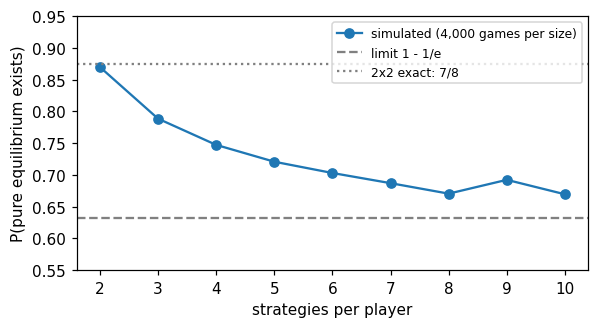

In [12]:
def has_pure_equilibrium(A, B):
    '''Vectorised check: is some cell a best response for both players?'''
    row_best = A == A.max(axis=0, keepdims=True)
    col_best = B == B.max(axis=1, keepdims=True)
    return bool((row_best & col_best).any())


rng = np.random.default_rng(0)
sizes = range(2, 11)
share = [np.mean([has_pure_equilibrium(rng.random((s, s)), rng.random((s, s))) for _ in range(4000)])
         for s in sizes]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(list(sizes), share, "o-", label="simulated (4,000 games per size)")
ax.axhline(1 - 1 / np.e, ls="--", color="grey", label="limit 1 - 1/e")
ax.axhline(7 / 8, ls=":", color="grey", label="2x2 exact: 7/8")
ax.set(xlabel="strategies per player", ylabel="P(pure equilibrium exists)", ylim=(0.55, 0.95))
ax.legend(fontsize=8); plt.show()

The simulation matches both the exact 2×2 value and the slow approach to the limit. Beyond being a check on the code, the result matters for design: in about a third of large random games the answer to a World 1 puzzle is "none", which is useful to know when balancing a level pack.

Now the generator itself.

In [13]:
def random_game(m, n, rng, low=0, high=9):
    '''Random game with integer payoffs in [low, high].'''
    return rng.integers(low, high + 1, (m, n)), rng.integers(low, high + 1, (m, n))


def max_denominator(values):
    '''Largest denominator needed to write the values as simple fractions.'''
    return max(Fraction(float(v)).limit_denominator(1000).denominator for v in values)


def game_features(A, B):
    '''Features of a game used for filtering and difficulty.

    Returns
    -------
    dict with keys
        shape, distinct_replies, equilibria, n_equilibria, n_pure, min_support, max_support,
        equal_supports, max_denominator, dominance_solvable
    '''
    eqs = support_enumeration(A, B)
    supports = [((x > TOL).sum(), (y > TOL).sum()) for x, y in eqs]
    distinct = (all(len(set(A[:, j])) == A.shape[0] for j in range(A.shape[1])) and
                all(len(set(B[i])) == B.shape[1] for i in range(B.shape[0])))
    rows, cols = eliminate_dominated(A, B)
    return dict(
        shape=f"{A.shape[0]}x{A.shape[1]}",
        distinct_replies=distinct,
        equilibria=eqs,
        n_equilibria=len(eqs),
        n_pure=sum(1 for sx, sy in supports if sx == 1 and sy == 1),
        min_support=min((min(s) for s in supports), default=0),
        max_support=max((max(s) for s in supports), default=0),
        equal_supports=all(sx == sy for sx, sy in supports),
        max_denominator=max((max_denominator(np.concatenate([x, y])) for x, y in eqs), default=1),
        dominance_solvable=len(rows) == 1 and len(cols) == 1,
    )


SPECS = {
    "dominance_3x3": dict(shape=(3, 3), dominance_solvable=True),
    "mixed_2x2":     dict(shape=(2, 2), n_equilibria=1, min_support=2, max_denominator=5),
    "mixed_3x3":     dict(shape=(3, 3), n_equilibria=1, min_support=2, max_denominator=8),
}


def satisfies(f, spec):
    '''Does a feature dict meet a specification? Nondegeneracy filters always apply.'''
    if not (f["distinct_replies"] and f["equal_supports"] and f["n_equilibria"] >= 1):
        return False
    if "dominance_solvable" in spec and f["dominance_solvable"] != spec["dominance_solvable"]:
        return False
    if "n_equilibria" in spec and f["n_equilibria"] != spec["n_equilibria"]:
        return False
    if "min_support" in spec and f["min_support"] < spec["min_support"]:
        return False
    if "max_denominator" in spec and f["max_denominator"] > spec["max_denominator"]:
        return False
    return True


def generate(spec, count, seed=0, max_tries=200_000):
    '''Generate-and-test: draw random games until `count` of them satisfy `spec`.

    Returns
    -------
    games : list of (A, B, features)
    acceptance : float
        Share of drawn games that were accepted.
    '''
    rng = np.random.default_rng(seed)
    games, tries = [], 0
    while len(games) < count and tries < max_tries:
        tries += 1
        A, B = random_game(*spec["shape"], rng)
        f = game_features(A, B)
        if satisfies(f, spec):
            games.append((A, B, f))
    return games, len(games) / tries

In [14]:
generated = {}
for name, spec in SPECS.items():
    games, acc = generate(spec, count=6, seed=1)
    generated[name] = games
    print(f"{name:15s} accepted {len(games)} games, acceptance rate {acc:.2%}")

dominance_3x3   accepted 6 games, acceptance rate 7.69%
mixed_2x2       accepted 6 games, acceptance rate 2.96%


mixed_3x3       accepted 6 games, acceptance rate 0.70%


The acceptance rates are themselves informative. Once the nondegeneracy filter is applied, about one random 3×3 game in thirteen is dominance-solvable. A 2×2 game with a unique, fully mixed equilibrium and "nice" probabilities is about one draw in thirty. For 3×3 games with a unique mixed equilibrium and denominators up to 8 it drops below one in a hundred, and requiring *full* support in 3×3 with small denominators essentially never happens with payoffs from 0 to 9 (try it by setting `min_support=3`). Rejection sampling is fine at these rates, but it would not scale to larger or more constrained puzzles. That is where the MILP generator planned for later comes in: instead of hoping to hit a game with the desired equilibrium, fix the equilibrium first and solve for payoffs that support it.

In [15]:
A, B, f = generated["mixed_2x2"][0]
x, y = f["equilibria"][0]
print("A =\n", A, "\nB =\n", B)
print("equilibrium: x =", [str(Fraction(float(p)).limit_denominator(20)) for p in x],
      " y =", [str(Fraction(float(p)).limit_denominator(20)) for p in y])

A =
 [[7 1]
 [3 9]] 
B =
 [[4 5]
 [2 1]]
equilibrium: x = ['1/2', '1/2']  y = ['2/3', '1/3']


In [16]:
# sanity checks
for name, games in generated.items():
    assert len(games) == 6, name
    for A, B, f in games:
        assert satisfies(f, SPECS[name])
        for x, y in f["equilibria"]:
            assert is_nash(A, B, x, y)
for A, B, f in generated["dominance_3x3"]:
    r, c = eliminate_dominated(A, B)
    assert pure_nash(A, B) == [(r[0], c[0])]          # the surviving cell is the unique equilibrium
print("✓ generator")

✓ generator


## 7 · How hard is a puzzle?

A generator without a notion of difficulty produces a random pile of levels. We need an ordering.

Two kinds of measures are available. **Structural** features are computed from the game: size, number of equilibria, support size, the denominators involved, whether dominance solves it. They are cheap and interpretable, but combining them into one number requires weights we do not know.

**Behavioural** measures ask how long some process takes to solve the puzzle. The natural candidate, suggested at the end of notebook 02, is regret matching: count the rounds until the NashConv of its average play drops below a threshold. It is a single number, it responds to everything that makes a game hard for adaptive play, and it needs no weights. It is only a proxy for human difficulty. Whether the two agree is an empirical question that the game itself can answer once people play it.

Details: the threshold is 1% of the payoff range, the result is the median over three seeds, and runs are capped at 10,000 rounds. NashConv is evaluated every 10 rounds to keep the computation cheap.

In [17]:
def learning_rounds(A, B, threshold=0.01, T=10_000, seeds=(0, 1, 2), every=10):
    '''Median number of regret-matching rounds until NashConv of the average play <= threshold * range.

    Parameters
    ----------
    A, B : np.ndarray, shape (m, n)
        Payoff matrices.
    threshold : float
        Target NashConv relative to the payoff range.
    T : int
        Cap on the number of rounds; runs that never reach the target count as T.
    seeds : iterable of int
        Random seeds of the regret-matching runs.
    every : int
        Evaluate NashConv every `every` rounds.

    Returns
    -------
    int
    '''
    A, B = np.asarray(A, float), np.asarray(B, float)
    target = threshold * payoff_range(A, B)
    hits = []
    for s in seeds:
        X, Y = regret_matching_averages(A, B, T, seed=s)
        hit = T
        for t in range(every - 1, T, every):
            if nash_conv(A, B, X[t], Y[t]) <= target:
                hit = t + 1
                break
        hits.append(hit)
    return int(np.median(hits))


def difficulty(A, B):
    '''Structural and behavioural difficulty features stored with every level.'''
    A, B = np.asarray(A, float), np.asarray(B, float)
    f = game_features(A, B)
    return dict(size=f["shape"], n_equilibria=f["n_equilibria"], max_support=int(f["max_support"]),
                max_denominator=int(f["max_denominator"]), dominance_solvable=f["dominance_solvable"],
                learning_rounds=learning_rounds(A, B))

In [18]:
for lv in world1 + world2:
    lv["difficulty"] = difficulty(lv["A"], lv["B"])

table = pd.DataFrame([{"id": lv["id"], "title": lv["title"], **lv["difficulty"]} for lv in world1 + world2])
table

,id,title,size,n_equilibria,max_support,max_denominator,dominance_solvable,learning_rounds
0,w1-01,Two Suspects,2x2,1,1,1,True,50
1,w1-02,The Market Leader,2x2,1,1,1,True,100
2,w1-03,Peel the Onion,3x3,1,1,1,True,110
3,w1-04,Which Side of the Road?,2x2,3,2,3,False,200
4,w1-05,Heads or Tails,2x2,1,2,2,False,2290
5,w1-06,The Enforcer,2x2,1,1,1,True,50
6,w2-01,The Fair Coin,2x2,1,2,2,False,2290
7,w2-02,Uneven Stakes,2x2,1,2,5,False,610
8,w2-03,Penalty Kick,2x2,1,2,19,False,330
9,w2-04,The Mixed Compromise,2x2,3,2,3,False,150


The measure separates two groups. Games with a pure equilibrium are learned in at most a couple of hundred rounds; games whose only equilibrium is mixed take hundreds to thousands, with rock-paper-scissors the slowest. That is the split between World 1 and World 2, recovered without being told.

Inside that picture, three results do not match intuition, and each one is instructive:

- **The Mixed Compromise** looks easy (about 150 rounds). Regret matching converges to one of the *pure* equilibria of battle of the sexes, while the level asks for the mixed one. The measure describes the game, not the task.
- **Heads or Tails** in World 1 gets the same high number as The Fair Coin, because it is the same game. But the World 1 task, "declare that there is no pure equilibrium", is easy. Again the game and the task disagree.
- **Penalty Kick** is rated easier than The Fair Coin, although for a person computing $10/19$ is much harder than seeing $1/2$ by symmetry. Arithmetic difficulty is invisible to a learning algorithm. The structural feature `max_denominator` captures it, so the two kinds of measures complement each other rather than compete.

The design level, finally, inherits the numbers of the prisoner's dilemma, which say nothing about the design task. For design levels a different measure is needed, such as the number of cells the optimal change touches.

These are exactly the mismatches worth recording. They are the starting point for the research question of the project: which features make a game hard for people, and do they agree with what makes it hard for learning algorithms?

In [19]:
gen_rows = []
for name, games in generated.items():
    for k, (A, B, f) in enumerate(games):
        d = difficulty(A, B)
        gen_rows.append({"spec": name, "k": k, **d})
gen_table = pd.DataFrame(gen_rows)
gen_table.groupby("spec")["learning_rounds"].describe()[["min", "50%", "max"]]

,min,50%,max
spec,,,
dominance_3x3,70.0,165.0,340.0
mixed_2x2,90.0,345.0,2000.0
mixed_3x3,190.0,550.0,1050.0


In [20]:
# sanity checks
assert all(lv["difficulty"]["learning_rounds"] < 10_000 for lv in world1 + world2)
with_pure = [lv["difficulty"]["learning_rounds"] for lv in world1 if lv["id"] != "w1-05"]
only_mixed = [lv["difficulty"]["learning_rounds"] for lv in world2 if lv["difficulty"]["n_equilibria"] == 1]
assert max(with_pure) < min(only_mixed), "games with a pure equilibrium should be learned faster"
print("✓ difficulty")

✓ difficulty


## 8 · Exporting the levels

Each world becomes one JSON file. Generated puzzles go into their own file, sorted by learning rounds, so the game can offer an endless mode that gets harder over time. Every level is validated again just before writing: whatever reaches the browser has been recomputed from the payoffs.

Generated levels get neutral texts. Writing stories for them is a good task for later, by hand or with templates.

In [21]:
def generated_level(spec_name, k, A, B):
    '''Wrap a generated game as a level with neutral texts.'''
    m, n = A.shape
    rows, cols = [f"R{i + 1}" for i in range(m)], [f"C{j + 1}" for j in range(n)]
    if spec_name.startswith("dominance"):
        lv = make_level(f"gen-{spec_name}-{k}", 0, k, f"Generated {A.shape[0]}x{A.shape[1]} #{k + 1}",
                        "Iterated elimination", "A randomly generated game.", "all_pure",
                        ["Row", "Column"], rows, cols, A, B,
                        ["Look for a strategy that is never the best reply, remove it, repeat."])
    else:
        lv = make_level(f"gen-{spec_name}-{k}", 0, k, f"Generated {A.shape[0]}x{A.shape[1]} #{k + 1}",
                        "Mixed equilibrium", "A randomly generated game.", "mixed",
                        ["Row", "Column"], rows, cols, A, B,
                        ["Find the mix that makes your opponent indifferent between the actions she uses."])
    lv["difficulty"] = difficulty(A, B)
    return lv


def export_world(levels, path):
    '''Validate every level and write the list to a JSON file.'''
    for lv in levels:
        validate_level(lv)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as fh:
        json.dump(levels, fh, indent=2, ensure_ascii=False)
    return path


gen_levels = [generated_level(name, k, A, B)
              for name, games in generated.items() for k, (A, B, f) in enumerate(games)]
gen_levels.sort(key=lambda lv: lv["difficulty"]["learning_rounds"])

# levels/ sits at the repository root; this notebook may be run from notebooks/ or from the root
LEVELS = Path("../levels") if Path.cwd().name == "notebooks" else Path("levels")

for levels, path in [(world1, LEVELS / "world1.json"), (world2, LEVELS / "world2.json"),
                     (gen_levels, LEVELS / "generated.json")]:
    export_world(levels, path)
    print(f"wrote {len(levels):2d} levels to {path}")

wrote  6 levels to levels/world1.json
wrote  5 levels to levels/world2.json
wrote 18 levels to levels/generated.json


In [22]:
print(json.dumps(world2[2], indent=2)[:1400])

{
  "id": "w2-03",
  "world": 2,
  "order": 3,
  "title": "Penalty Kick",
  "concept": "Minimax in the field",
  "story": "A kicker shoots left or right; the goalkeeper dives left or right. Numbers are the chance of a goal in percent for the kicker, and the chance of a save for the keeper. The kicker is stronger on her left.",
  "task": "mixed",
  "players": [
    "Kicker",
    "Keeper"
  ],
  "row_labels": [
    "Shoot left",
    "Shoot right"
  ],
  "col_labels": [
    "Dive left",
    "Dive right"
  ],
  "A": [
    [
      50.0,
      95.0
    ],
    [
      90.0,
      40.0
    ]
  ],
  "B": [
    [
      50.0,
      5.0
    ],
    [
      10.0,
      60.0
    ]
  ],
  "hints": [
    "The keeper must be indifferent between diving left and right. What does that say about the kicker's mix?",
    "Real kickers shoot to their stronger side a bit more than half the time. Does your answer agree?"
  ],
  "check": {
    "type": "nash_conv",
    "tolerance": 2.7,
    "require_fully_mixed": 

In [23]:
# sanity checks: read the files back and validate again
for path in [LEVELS / "world1.json", LEVELS / "world2.json", LEVELS / "generated.json"]:
    with open(path, encoding="utf-8") as fh:
        for lv in json.load(fh):
            validate_level(lv)
print("✓ exported files round-trip")

✓ exported files round-trip


## 9 · Discussion

**What the browser needs to implement.** Three answer checks: set equality for `pure_set`, NashConv against a tolerance (plus the fully-mixed condition) for `nash_conv`, and the two inequalities plus a cost comparison for `design`. All three are a few lines each. No solver runs in the browser.

**Where the generator goes next.** Rejection sampling is transparent and correct, but its acceptance rates fall quickly as the specification tightens. The planned MILP generator inverts the process: choose the equilibrium first (supports and probabilities with small denominators), then search for integer payoffs in a range that make it the unique equilibrium, with the indifference conditions as linear constraints and uniqueness enforced by requiring every other support pair to fail. The design-mode LP in section 5 is a small first step in that direction, since it already solves for payoffs given an equilibrium.

**On difficulty.** The learning-rounds measure is a hypothesis, not a fact about people. The game can test it: log how long players take and how many attempts they need, then compare with the structural features and the learning measure. If regret matching and humans disagree on some class of games, that disagreement is a small research result in itself.

**On the stories.** The hand-built levels borrow classic settings (the prisoners, market entry, the road, penalty kicks) because a familiar story makes the payoffs readable. The penalty-kick level is a reminder that mixed equilibria are not only a theoretical device: they are tested, with some success, on real behaviour.

---
## References

**Game theory and computation**

- Shoham, Y., & Leyton-Brown, K. (2009). *Multiagent Systems: Algorithmic, Game-Theoretic, and Logical Foundations*. Cambridge University Press.
- von Stengel, B. (2002). Computing equilibria for two-person games. In R. J. Aumann & S. Hart (Eds.), *Handbook of Game Theory with Economic Applications* (Vol. 3, pp. 1723–1759). Elsevier.
- Hart, S., & Mas-Colell, A. (2000). A simple adaptive procedure leading to correlated equilibrium. *Econometrica*, 68(5), 1127–1150.

**Random games**

- Goldberg, K., Goldman, A. J., & Newman, M. (1968). The probability of an equilibrium point. *Journal of Research of the National Bureau of Standards*, 72B(2), 93–101.
- Dresher, M. (1970). Probability of a pure equilibrium point in n-person games. *Journal of Combinatorial Theory*, 8(1), 134–145.
- Nudelman, E., Wortman, J., Shoham, Y., & Leyton-Brown, K. (2004). Run the GAMUT: A comprehensive approach to evaluating game-theoretic algorithms. *Proceedings of the 3rd International Joint Conference on Autonomous Agents and Multiagent Systems (AAMAS)*, 880–887.

**Procedural content generation**

- Togelius, J., Yannakakis, G. N., Stanley, K. O., & Browne, C. (2011). Search-based procedural content generation: A taxonomy and survey. *IEEE Transactions on Computational Intelligence and AI in Games*, 3(3), 172–186.
- Shaker, N., Togelius, J., & Nelson, M. J. (2016). *Procedural Content Generation in Games*. Springer.

**Inverse optimisation and inverse games**

- Ahuja, R. K., & Orlin, J. B. (2001). Inverse optimization. *Operations Research*, 49(5), 771–783.
- Waugh, K., Ziebart, B. D., & Bagnell, J. A. (2011). Computational rationalization: The inverse equilibrium problem. *Proceedings of the 28th International Conference on Machine Learning (ICML)*, 1169–1176.
- Kuleshov, V., & Schrijvers, O. (2015). Inverse game theory: Learning utilities in succinct games. *Web and Internet Economics (WINE)*, Lecture Notes in Computer Science 9470, 413–427.

**Mixed strategies in the field**

- Chiappori, P.-A., Levitt, S., & Groseclose, T. (2002). Testing mixed-strategy equilibria when players are heterogeneous: The case of penalty kicks in soccer. *American Economic Review*, 92(4), 1138–1151.
- Palacios-Huerta, I. (2003). Professionals play minimax. *Review of Economic Studies*, 70(2), 395–415.

---
### Where these functions go next

`make_level`, `validate_level` and `export_world` become `engine/levels.py`; the generator and difficulty measures become `engine/generator.py`; `min_change_to_equilibrium` joins the solvers. The `levels/` folder is what the web front end reads. Next step: the browser game.